# YZM304 Derin Öğrenme Projesi

## 1. Kütüphaneler

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.neural_network import MLPClassifier

## 2. Veri Setinin Yüklenmesi

In [22]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. Veri Analizi

In [23]:
print("Veri boyutu:", df.shape)
print("\nSütun isimleri:")
print(df.columns)

Veri boyutu: (299, 13)

Sütun isimleri:
Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')


In [24]:
print("Eksik veri sayıları:")
print(df.isnull().sum())

Eksik veri sayıları:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [25]:
print("Sınıf dağılımı:")
print(df["DEATH_EVENT"].value_counts())

Sınıf dağılımı:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [26]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## 4. Veri Ön İşleme

In [27]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [28]:
print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (299, 12)
y boyutu: (299,)


In [29]:
# Önce train (%70) ve temp (%30) ayır
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Temp'i ikiye böl → validation (%15) + test (%15)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Boyutları kontrol et
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (209, 12)
Validation: (45, 12)
Test: (45, 12)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 5. Temel Model

In [32]:
basic_model = MLPClassifier(
    hidden_layer_sizes=(8,),   # 1 gizli katman, 8 nöron
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)

basic_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(8,)"
,activation,'relu'
,solver,'sgd'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [33]:
# Tahminler
y_train_pred = basic_model.predict(X_train_scaled)
y_val_pred = basic_model.predict(X_val_scaled)
y_test_pred = basic_model.predict(X_test_scaled)

# Accuracy hesapla
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9234449760765551
Validation Accuracy: 0.7777777777777778
Test Accuracy: 0.7111111111111111


In [34]:
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        31
           1       0.55      0.43      0.48        14

    accuracy                           0.71        45
   macro avg       0.66      0.63      0.64        45
weighted avg       0.70      0.71      0.70        45

Confusion Matrix:
[[26  5]
 [ 8  6]]


## 6. Geliştirilmiş Model

In [35]:
improved_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),   # 2 gizli katman
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=500,
    alpha=0.001,   # L2 regularization
    random_state=42
)

improved_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [36]:
# Tahminler
y_train_pred2 = improved_model.predict(X_train_scaled)
y_val_pred2 = improved_model.predict(X_val_scaled)
y_test_pred2 = improved_model.predict(X_test_scaled)

# Accuracy hesapla
train_acc2 = accuracy_score(y_train, y_train_pred2)
val_acc2 = accuracy_score(y_val, y_val_pred2)
test_acc2 = accuracy_score(y_test, y_test_pred2)

print("Train Accuracy:", train_acc2)
print("Validation Accuracy:", val_acc2)
print("Test Accuracy:", test_acc2)

Train Accuracy: 0.937799043062201
Validation Accuracy: 0.8
Test Accuracy: 0.7111111111111111


In [37]:
print("Classification Report (Improved Model - Test Set):")
print(classification_report(y_test, y_test_pred2))

print("Confusion Matrix (Improved Model):")
print(confusion_matrix(y_test, y_test_pred2))

Classification Report (Improved Model - Test Set):
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.53      0.64      0.58        14

    accuracy                           0.71        45
   macro avg       0.68      0.69      0.68        45
weighted avg       0.73      0.71      0.72        45

Confusion Matrix (Improved Model):
[[23  8]
 [ 5  9]]


## 7. Sonuçların Karşılaştırılması

In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Temel Model", "Geliştirilmiş Model"],
    "Train Accuracy": [train_acc, train_acc2],
    "Validation Accuracy": [val_acc, val_acc2],
    "Test Accuracy": [test_acc, test_acc2]
})

results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,Temel Model,0.923445,0.777778,0.711111
1,Geliştirilmiş Model,0.937799,0.800000,0.711111


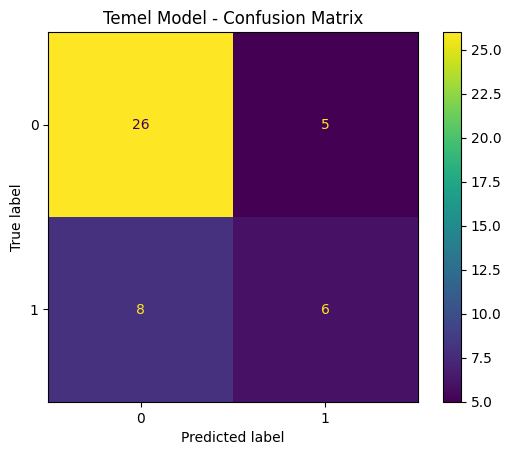

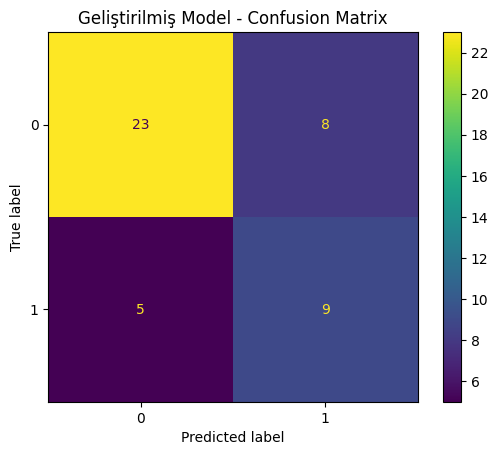

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

# Temel model confusion matrix
ConfusionMatrixDisplay.from_estimator(
    basic_model, X_test_scaled, y_test
)
plt.title("Temel Model - Confusion Matrix")
plt.show()

# Geliştirilmiş model confusion matrix
ConfusionMatrixDisplay.from_estimator(
    improved_model, X_test_scaled, y_test
)
plt.title("Geliştirilmiş Model - Confusion Matrix")
plt.show()

## 8. Nihai Değerlendirme

## Model Karşılaştırması ve Nihai Model Seçimi

Temel model ile geliştirilmiş model karşılaştırıldığında, her iki modelin test doğruluğu benzer bulunmuştur. Ancak geliştirilmiş model, özellikle pozitif sınıf olan `DEATH_EVENT = 1` için daha yüksek recall ve F1-score üretmiştir. 

Bu nedenle, klinik açıdan daha kritik olan ölüm olaylarını daha iyi tahmin edebildiği için **geliştirilmiş model nihai model olarak seçilmiştir**.